# 네이버 블로그에서 [서울 버거 맛집] 웹크로링 데이터 약 500개 - 전처리

In [ ]:
# 네이버 블로그에서 [서울 버거 맛집] 웹크로링 데이터 약 500개 - 전처리

import pandas as pd
import re
import csv
from konlpy.tag import Okt

# csv 로 저장된 파일 열기
df = pd.read_csv('서울_버거_맛집_500.csv')

# title 컬럼에 대한 데이터 전처리 ( re, pandas )

# 가 정규식을 사용해서 데이터 전처리
# 가-1. 정규식을 사용해서 특수문자 제거 (한글, 영어, 숫자, 공백 제외)
df['title'] = df['title'].str.replace(r'[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9 ]', '', regex=True)
# 가-2. 정규식으로 연도, 월 정보 제거 
df['title'] = df['title'].str.replace(r'\d{4}년?\s*\d{1,2}월?', '', regex=True)
df['title'] = df['title'].str.replace(r'\b\d{4}[.\s]?\d{1,2}\b\s?', '', regex=True)

# 나 표준화
# 나-1. 영문자 대문자 -> 소문자로
df['title'] = df['title'].str.lower()
# df['title'] = df['title'].str.replace('[a-zA-Z]', '', regex=True) # 옵션 : 영문자 제외

# 다 데이터 가공
# 다-1 title, content 에 데이터가 없으면 삭제
df = df.dropna(subset=['title', 'content'])

# 다-2 title 에 데이터가 중복이 경우
df = df.drop_duplicates(subset=['title'])

# 라 기타 데이터 제거
# title 컬럼에 제주, 부산 있는지 확인? 과천, 제주, 부산, 괌 인경우 행을 삭제
# df[df['title'].str.contains('제주')]
# 라-1 서울이 아닌 지역이 있으면 행 제거
df = df[~df['title'].str.contains('과천|제주|부산|괌|양평', na=False)]

# 라-2 불용어 (STOPWORD) 를 제거
stopwords = ["에서", "까지", "와", "과", "의", "로","이","가","는", "보다"] # 샘플로 10개만 
pattern = "|".join(stopwords)
df["title"] = df["title"].str.replace(pattern, "", regex=True)

# 라-3 연속된 공백제거하여 한개 공백
df["title"] = df["title"].str.replace(r'\s+', ' ', regex=True)

#df.iloc[0:50]
#print(len(df)) # 203 -> 202(중복) -> 다른지역(5개-197)

# content 컬럼에 대한 데이터 전처리 ( re, pandas, konlpy )
okt = Okt()
 
def clean_blog_content(text) :
    # 결측치(NaN) 처리
    if not isinstance(text, str):
        return ""
    # 가-1 
    # URL 제거 패턴
    url_pattern = r'https?://[a-zA-Z0-9\-.:/?=&_]+'
    # 이메일 제거 패턴
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    # 특수문자 제거 패턴 (한글, 영문, 숫자, 공백만 남김)
    special_pattern = r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9\s]'

    # 순차적으로 정규식 적용
    text = re.sub(url_pattern, '', text)
    text = re.sub(email_pattern, '', text)
    text = re.sub(special_pattern, '', text)

    # 연속된 공백 하나로 줄이기 및 앞뒤 공백 제거
    text = re.sub(r'\s+', ' ', text)

    # 나-1 konlpy를 적용 - 명사 추출
    nouns = okt.nouns(text)
    # '것', '수', '등'과 같은 의미 없는 1글자 불용어 제거
    # 나-2 제거하고 싶은 불용어 리스트 정의
    stop_words = ['정말', '진짜', '오늘', '이번', '로그', '블로그', '네이버', '대박', '사건']
    nouns = [noun for noun in nouns if (noun not in stop_words) and (len(noun) > 1 or noun == '맛')]
    
    return " ".join(nouns)

#  clean_blog_content 함수를 df 적용
df['content_clean'] = df['content'].apply(clean_blog_content)

df.iloc[0:50]

# 데이터 중간 저장
output_file = '서울_버거_맛집_500_전처리_2.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print('CSV_전처리_2 파일 저장완료')

# 텍스트마이닝: 네이버 블로그 - 서울 버거 맛집 500개

In [11]:
# 모듈 불러오기
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 파일 열기
df = pd.read_csv('서울_버거_맛집_500_전처리-2.csv')

# 결측데이터 삭제, 공백으로 대체
df['content_clean'] = df['content_clean'].fillna('')

# DTM 생성
vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
dtm_matrix = vectorizer.fit_transform(df['content_clean'])

dtm_df = pd.DataFrame(
    dtm_matrix.toarray(),
    columns = vectorizer.get_feature_names_out()
)

# 전체 단어의 빈도를 계산
word_frequencies = dtm_df.sum(axis=0)

# 주관적인 목록 : 아래 목록에 (무슨) 버거 몇 개 나오는지 확인
target_burgers = [
    '불고기버거', '새우버거', '치킨버거', '치즈버거', '달걀버거', 
    '스테이크버거', '떡갈비버거', '밥버거', '햄버거', '바게트버거'
]

# 타겟이 되는 목록이 존재하는 데이터를 찾아봄
existing_burgers = [burger for burger in target_burgers if burger in word_frequencies.index]

# 빈도수를 추출 
burger_count_df = pd.DataFrame({
    '버거 종류': existing_burgers,
    '빈도수': [word_frequencies[burger] for burger in existing_burgers]
})

target_df = pd.DataFrame({'버거 종류': target_burgers})

# 데이터 병합
result_df = pd.merge(target_df, burger_count_df, on='버거 종류', how='left')
result_df['빈도수'] = result_df['빈도수'].fillna(0).astype(int)

# 정렬 후 결과를 다시 변수에 덮어쓰기
burger_count_df = result_df.sort_values(by='빈도수', ascending=False).reset_index(drop=True)
print(burger_count_df)


# csv 저장
burger_count_df.to_csv('burger_count.csv', index=False, encoding = 'utf-8-sig')
print('csv 파일 저장 완료: burger_count.csv')

    버거 종류   빈도수
0     햄버거  1768
1    치즈버거   704
2    새우버거   168
3    치킨버거   137
4   불고기버거    32
5  스테이크버거    28
6    달걀버거     0
7   떡갈비버거     0
8     밥버거     0
9   바게트버거     0
csv 파일 저장 완료: burger_count.csv


In [10]:
# 기존 코드에서 생성된 word_frequencies가 있다고 가정합니다.
# word_frequencies는 단어 이름이 '인덱스'이고, 등장 횟수가 '값'인 판다스 시리즈(Series)입니다.

# 1. 내가 찾고 싶은 타겟 재료 목록 정의
target_ingredients = [ 
    '번', '패티', '치즈', '양상추', '토마토',  
    '양파', '마요네즈', '케첩', '피클', '베이컨' 
]

# 2. [핵심] reindex()를 사용하여 타겟 목록만 쏙 뽑아오고, 없는 건 0으로 채우기
# - fill_value=0 : 데이터에 해당 재료가 없을 때 NaN 대신 0을 집어넣어라
ingredient_series = word_frequencies.reindex(target_ingredients, fill_value=0)

# 3. 데이터프레임(표) 형태로 예쁘게 변환
ingredient_count_df = pd.DataFrame({
    '재료 종류': ingredient_series.index,
    '빈도수': ingredient_series.values
})

# 4. 많이 언급된 순서대로 내림차순 정렬 및 순번(인덱스) 초기화
ingredient_count_df = ingredient_count_df.sort_values(by='빈도수', ascending=False).reset_index(drop=True)

# 5. 결과 출력
print(ingredient_count_df)

# csv 저장
ingredient_count_df.to_csv('ingredient_count.csv', index=False, encoding = 'utf-8-sig')
print('csv 파일 저장 완료: ingredient_count.csv')

  재료 종류   빈도수
0    패티  1510
1    치즈  1048
2   베이컨   467
3    양파   361
4    피클   266
5   토마토   227
6   양상추   123
7    케첩   117
8  마요네즈    80
9     번     0
csv 파일 저장 완료: ingredient_count.csv


# 데이터시각화

## 워드클라우드

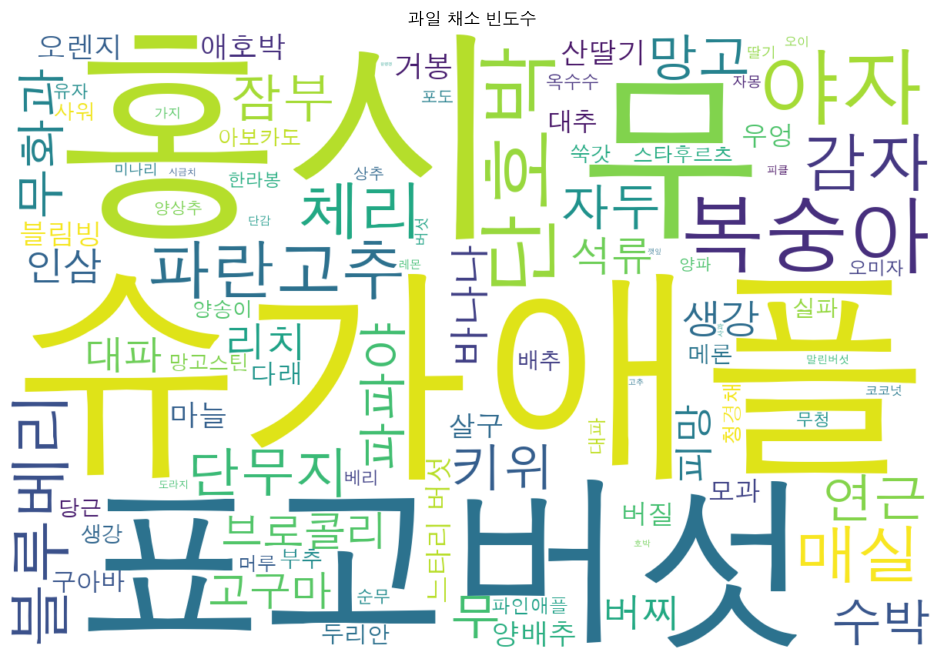

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('fruit_vegetable.csv')

freq_dict = dict(zip(df['title'], df['count']))

wordcloud = WordCloud(
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf',   # 한글폰트지정
    width = 1200,
    height = 800,
    background_color = 'white').generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,8))   # 12인치, 8인치
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('과일 채소 빈도수')
plt.show()

In [ ]:
# 1. 시각화 및 데이터 처리에 필요한 필수 모듈 불러오기
import pandas as pd
import matplotlib.pyplot as plt                 # 데이터 시각화(그래프 틀 생성)를 위한 라이브러리
from wordcloud import WordCloud                 # 워드클라우드 이미지 생성을 위한 라이브러리

# ==========================================
# 🔥 [한글 깨짐 해결] 그래프 기계(Matplotlib) 전역 설정
# ==========================================
# plt.title()이나 축 이름 등 그래프 '바깥쪽 틀'의 글자가 네모(□)로 깨지는 것을 막아줍니다.
plt.rcParams['font.family'] = 'AppleGothic'    # 맥(Mac) 시스템의 기본 서체인 '애플고딕'을 전역 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False     # 그래프에 마이너스 기호(-)가 있을 때 깨지는 현상 방지

# 2. 전처리가 완료된 빈도수 CSV 파일 불러오기
df = pd.read_csv('fruit_vegetable.csv')

# 3. 데이터프레임(표)의 내용을 워드클라우드 전용 형태인 '딕셔너리'로 변환
# - zip(df['title'], df['count']) : 과일/채소 이름과 개수를 하나씩 1:1로 짝지어줍니다.
# - dict(...) : 최종적으로 {'사과': 150, '바나나': 80} 구조의 딕셔너리를 생성합니다.
freq_dict = dict(zip(df['title'], df['count']))

# 4. 워드클라우드 이미지 생성 및 세부 옵션 설정
# - font_path : 이미지 '안쪽 알맹이 글자'들이 깨지지 않도록 맥의 실제 폰트 파일 경로를 직접 지정
# - width, height : 저장되거나 화면에 보일 워드클라우드 이미지의 가로/세로 해상도(픽셀 크기)
# - background_color : 도화지 배경색을 깔끔한 하얀색으로 설정 (기본값은 검은색)
# - generate_from_frequencies(freq_dict) : 위에서 짝지어둔 빈도수 딕셔너리를 갈아 넣어 최종 이미지 생성
wordcloud = WordCloud(
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf',   
    width = 1200,
    height = 800,
    background_color = 'white'
).generate_from_frequencies(freq_dict)

# 5. 완성된 워드클라우드 이미지를 화면에 띄우기
plt.figure(figsize=(12, 8))                     # 시각화 창 크기를 가로 12인치, 세로 8인치 큼직하게 설정

# - imshow : 수치 데이터 상태인 워드클라우드를 진짜 눈에 보이는 '이미지 그림'으로 변환하여 출력
# - interpolation='bilinear' : 글자가 대폭 커지거나 작아질 때 외곽선이 깨지지 않고 부드럽게 보이도록 보정
plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')                                 # 그래프 기본값인 가로축/세로축 눈금선과 테두리를 숨김 (포스터처럼 깔끔하게 보기 위함)
plt.title('과일 채소 빈도수', fontsize=16)       # 그래프 맨 위에 표시될 메인 제목 설정 (맨 위에서 폰트 설정을 했기에 한글이 완벽히 나옵니다)
plt.show()                                      # 모든 세팅이 반영된 최종 완성본 그림을 화면에 깨끗하게 출력

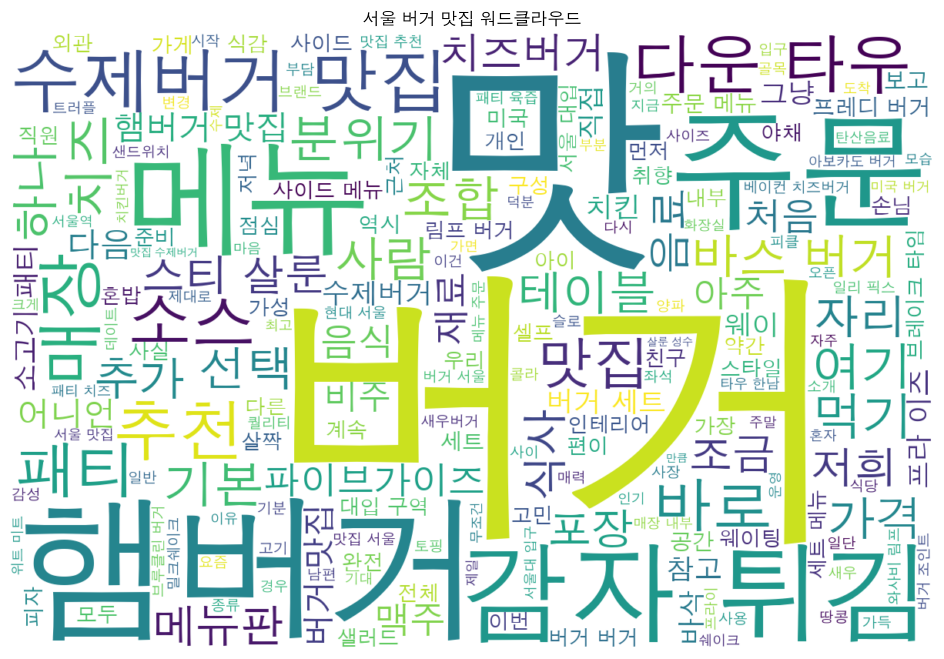

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. 그래프 폰트 및 마이너스 깨짐 설정
plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치

# 2. 데이터 불러오기
df = pd.read_csv('서울_버거_맛집_500_전처리-2.csv')

# 3. 텍스트 데이터 하나로 합치기 (결측치 제거)
text = " ".join(df['content_clean'].dropna())

# 4. 일반적인 사각형 워드클라우드 생성
wordcloud = WordCloud(
    font_path='/System/Library/Fonts/Supplemental/AppleGothic.ttf', # 한글 폰트 지정
    width=1200,
    height=800,
    background_color='white'
).generate(text)

# 5. 시각화 출력
plt.figure(figsize=(12, 8))   # 가로 12인치, 세로 8인치
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')               # 축 억제 (일반적인 워드클라우드 형태)
plt.title('서울 버거 맛집 워드클라우드')
plt.show()

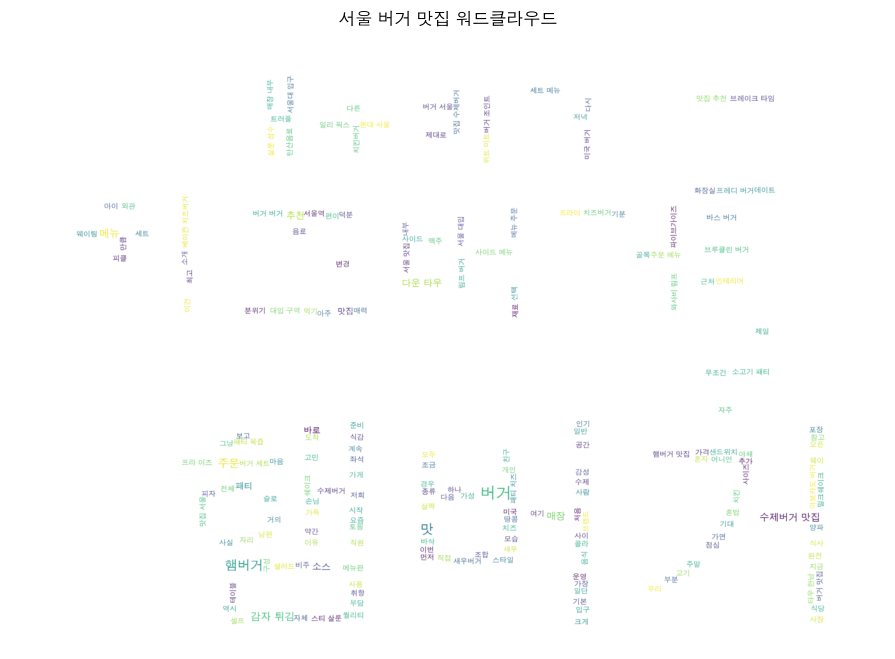

In [30]:
# 강사님 버전

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


img = Image.open('/Users/garyungkim/Desktop/my_work/my_venv/image/burger.png')

img = Image.open('/Users/garyungkim/Desktop/my_work/my_venv/image/burger.png').convert("RGBA")
# 1. 원본 이미지와 똑같은 크기의 순수 흰색(255, 255, 255, 255) 도화지 생성
white_bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
# 2. 흰색 도화지 위에 투명한 버거 이미지를 위에 덮어씌우기(합성)
img_filled = Image.alpha_composite(white_bg, img).convert("RGB")
# 3. 완성된 이미지를 넘파이 배열로 변환
imgArray = np.array(img_filled)   # 원하는 모양의 이미지 불러와서 행렬(Array)로 변환


df = pd.read_csv('서울_버거_맛집_500_전처리-2.csv')

text = " ".join(df['content_clean'].dropna())

wordcloud = WordCloud(
    font_path= '/System/Library/Fonts/Supplemental/AppleGothic.ttf', # 한글폰트지정
    width=1200,
    height=800,
    background_color = 'white',
    mask=imgArray).generate(text)   # 워드클라우드가 그려질 '틀(배경 모양)'을 지정하는 옵션

plt.figure(figsize=(12,8)) # 12인치, 8인치
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('서울 버거 맛집 워드클라우드')
plt.show()

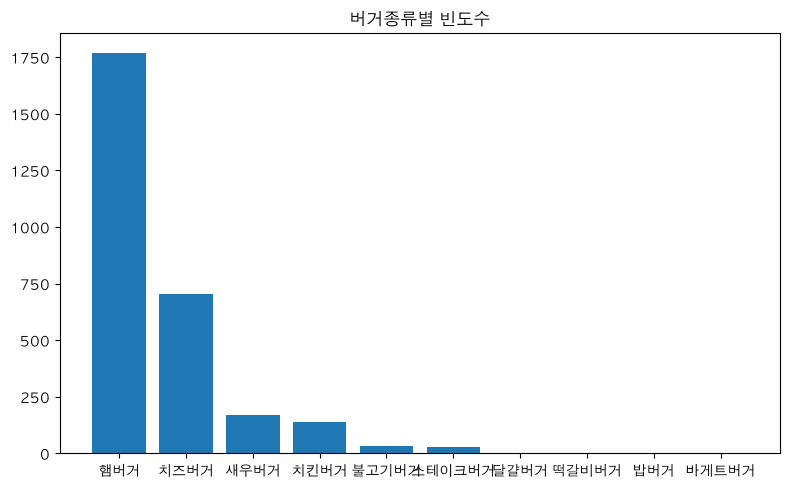

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('burger_count.csv')
plt.figure(figsize=(8,5))
plt.bar(df['버거 종류'], df['빈도수'])
plt.title('버거종류별 빈도수')
plt.tight_layout()
plt.show()

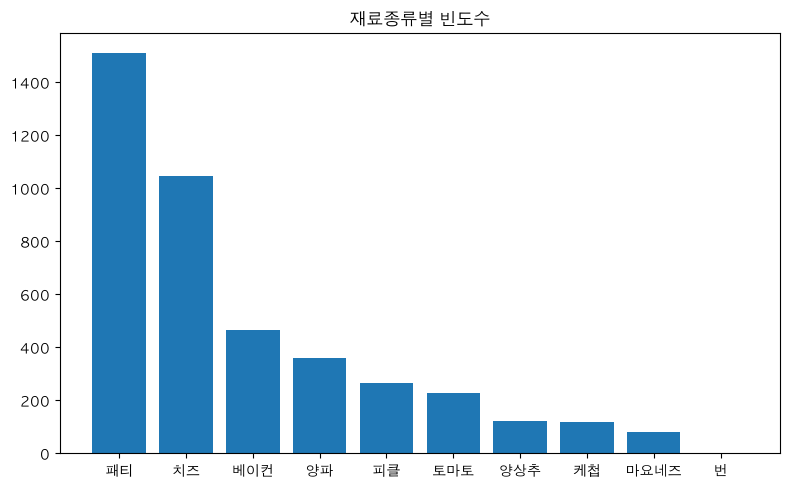

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('ingredient_count.csv')
plt.figure(figsize=(8,5))
plt.bar(df['재료 종류'], df['빈도수'])
plt.title('재료종류별 빈도수')
plt.tight_layout()
plt.show()

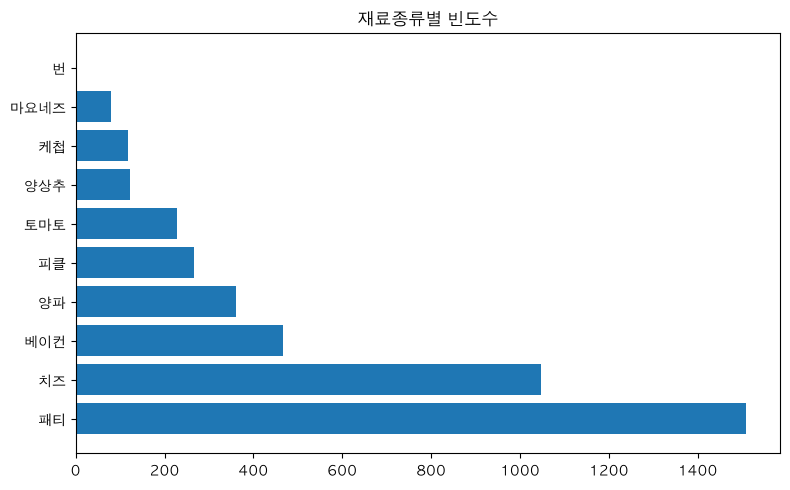

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('ingredient_count.csv')
plt.figure(figsize=(8,5))
plt.barh(df['재료 종류'], df['빈도수'])   # 가로 막대형으로 변경
plt.title('재료종류별 빈도수')
plt.tight_layout()
plt.show()

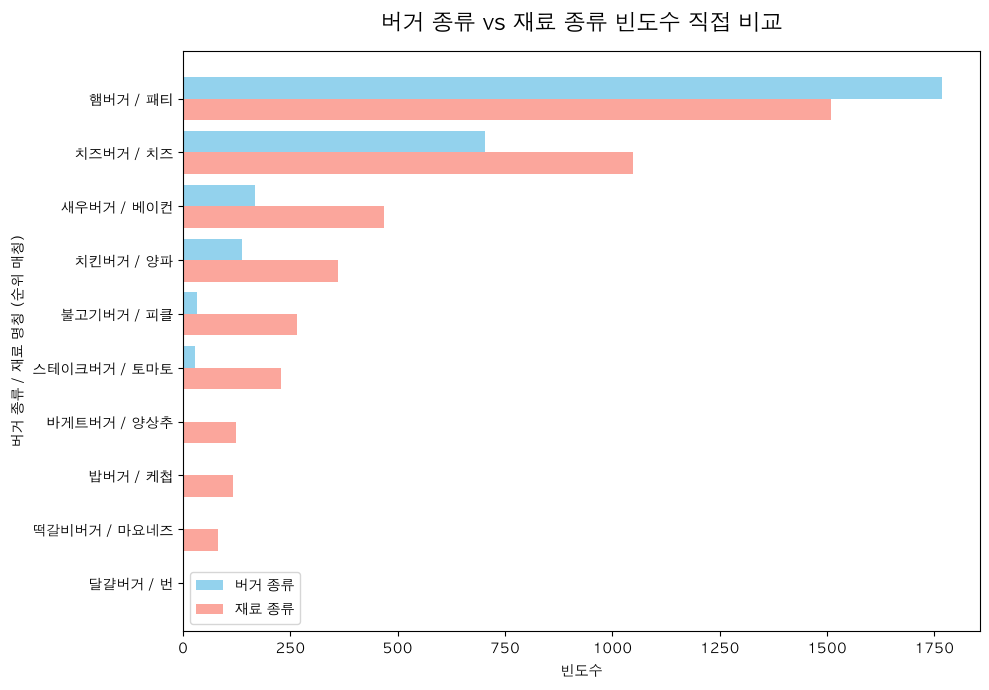

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data and sort descending (highest at the top)
df_burger = pd.read_csv('burger_count.csv').sort_values(by='빈도수', ascending=True).reset_index(drop=True)
df_ingredient = pd.read_csv('ingredient_count.csv').sort_values(by='빈도수', ascending=True).reset_index(drop=True)

# 2. Font configuration
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

# 3. Define positioning arrays
y_indices = np.arange(len(df_burger)) # [0, 1, 2, ... 9]
bar_height = 0.4  # Thick enough to look overlapped/grouped

plt.figure(figsize=(10, 7))

# Plot Burgers (shifted slightly up)
plt.barh(y_indices + bar_height/2, df_burger['빈도수'], height=bar_height, 
         label='버거 종류', color='skyblue', alpha=0.9)

# Plot Ingredients (shifted slightly down)
plt.barh(y_indices - bar_height/2, df_ingredient['빈도수'], height=bar_height, 
         label='재료 종류', color='salmon', alpha=0.7)

# 4. Custom Y-axis Labels combining both item names
combined_labels = [f"{b} / {i}" for b, i in zip(df_burger['버거 종류'], df_ingredient['재료 종류'])]
plt.yticks(y_indices, combined_labels)

plt.title('버거 종류 vs 재료 종류 빈도수 직접 비교', fontsize=16, pad=15)
plt.xlabel('빈도수')
plt.ylabel('버거 종류 / 재료 명칭 (순위 매칭)')
plt.legend() # Displays the labels color key box
plt.tight_layout()
plt.show()

## 파이차트

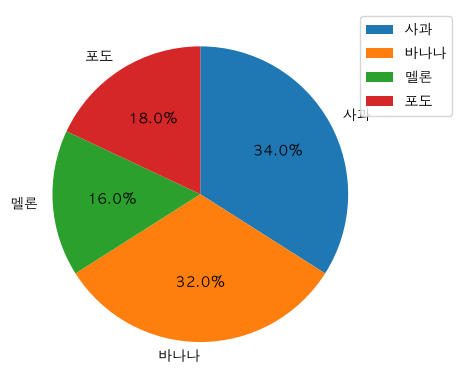

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 파이 그래프의 비율 %
ratio = [34, 32, 16, 18]
labels = ['사과', '바나나', '멜론', '포도']

# 파이 설정
plt.pie(ratio, labels=labels, autopct = '%.1f%%', startangle=90, counterclock=False)

# 범주
total = sum(ratio) # 전체 합계
legend_labels = [f'{label} ({(val/total)*100:,.1f}%)' for label, val in zip(labels, ratio)]
plt.legend(labels, loc = 'upper right', bbox_to_anchor = (1.2, 1))

plt.show()

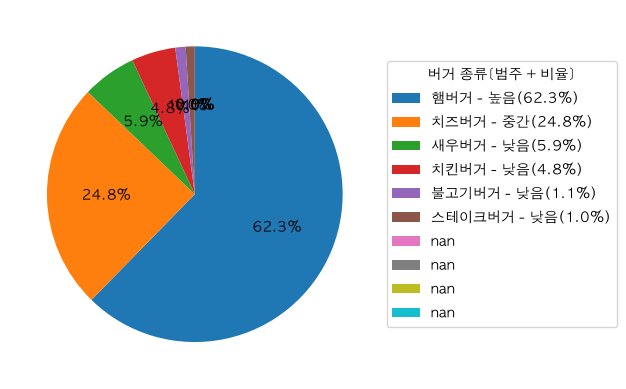

In [68]:
# 모듈 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 파일 열기
df = pd.read_csv('burger_count.csv')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

# 범주에 표시하기 위한 비율 계산
df['비율'] = df['빈도수'] / df['빈도수'].sum() * 100

bins  =[0, 10, 30, 100]
labels = ['낮음', '중간', '높음']
df['범주'] = pd.cut(df['비율'], bins=bins, labels=labels)

# 비율 + 범주를 합쳐서 표시 문자열 생성
df['표시'] = df['범주'].astype(str) + '(' + df['비율'].round(1).astype(str) + '%)'

# 파이 차트
wedges, texts, autotexts = plt.pie(df['빈도수'], labels=None, autopct = '%1.1f%%', startangle=90, counterclock=False)

# 범주
# 버거 종류 + 표시 합침
legend_labels = df['버거 종류'] + " - " + df['표시']
plt.legend(wedges, legend_labels, 
           title="버거 종류[범주 + 비율]", 
           loc='center left', 
           bbox_to_anchor=(1, 0.5) )
plt.show()

# 네이버 댓글 수집

In [ ]:
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import csv
import time
import re

csvfile = open(
    "서울_버거_맛집_500_댓글_2500.csv",
    "w",
    newline="",
    encoding="utf-8-sig"
)

writer = csv.writer(csvfile)
writer.writerow([
    "post_id",
    "comment",
    "rep_date"
])

browser = webdriver.Chrome()

headers = {
    "User-Agent":
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36"
}

keyword = "서울 버거 맛집"

# 먼저 링크만 수집
blog_links = []

for page in range(1, 75):

    url = (
        "https://section.blog.naver.com/Search/Post.naver"
        f"?pageNo={page}&rangeType=ALL&orderBy=sim&keyword={keyword}"
    )

    browser.get(url)
    time.sleep(2)

    soup = BeautifulSoup(
        browser.page_source,
        "lxml"
    )

    blogs = soup.find_all(
        "div",
        attrs={"class": "multi_pic"}
    )

    for blog in blogs:

        link = blog.find("a")["href"]
        post_id = link.split("/")[-1]

        blog_links.append(
            (
                post_id,
                link
            )
        )

print("수집된 링크 수 :", len(blog_links))

# 댓글 수집
for idx, (post_id, link) in enumerate(blog_links):

    try:

        print(
            f"[{idx+1}/{len(blog_links)}] 처리중 : {post_id}"
        )

        res = requests.get(
            link,
            headers=headers
        )

        soup_detail = BeautifulSoup(
            res.text,
            "lxml"
        )

        iframe = soup_detail.find(
            "iframe",
            id="mainFrame"
        )

        if iframe is None:
            continue

        iframe_url = (
            "https://blog.naver.com"
            + iframe["src"]
        )

        browser.get(iframe_url)
        time.sleep(2)

        # 댓글 버튼
        comment_btn = browser.find_element(By.CSS_SELECTOR, "div.area_comment.pcol2")

        if comment_btn :
            comment_btn.click()
            time.sleep(2)  
            
            log_no = re.search(r'logNo=(\d+)', iframe_url).group(1)
            print(log_no)
    
            # comment_div = browser.find_element(By.ID, "naverComment_201_224297251232")
            comment_div = browser.find_element(By.CSS_SELECTOR, f'div[id*="{log_no}"]')
            print(comment_div.get_attribute("id"))
            #print(comment_div.get_attribute("innerHTML"))
        else :
            print("댓글 버튼 없음")
            
       

        time.sleep(3)

        log_no = re.search(
            r'logNo=(\d+)',
            iframe_url
        ).group(1)
        
        comment_div = WebDriverWait(
            browser,
            10
        ).until(
            EC.presence_of_element_located(
                (
                    By.CSS_SELECTOR,
                    f'div[id*="{log_no}"]'
                )
            )
        )

        comments = browser.find_elements(
            By.CSS_SELECTOR,
            "span.u_cbox_contents"
        )

        comment_dates = browser.find_elements(
            By.CSS_SELECTOR,
            "span.u_cbox_date"
        )

        print(
            "댓글 수 :",
            len(comments)
        )

        for i in range(
            min(
                len(comments),
                len(comment_dates)
            )
        ):

            writer.writerow([
                post_id,
                comments[i].text,
                comment_dates[i].text
            ])

    except Exception as e:

        print(
            f"오류 발생 : {post_id}"
        )
        print(type(e).__name__)
        continue

browser.quit()
csvfile.close()

print("CSV 저장 완료")


# 블로그 댓글 전처리

In [ ]:
import pandas as pd
import re
from konlpy.tag import Okt

# 1. 파일 읽기
df = pd.read_csv('서울_버거_맛집_500_댓글_2500_1.csv')

# 2. 기본 확인
print(df.head())
print(df.info())

# 3. 결측값 처리
df['comment'] = df['comment'].fillna('').astype(str)

# 4. 형태소 분석기
okt = Okt()

# 5. 텍스트 전처리 함수
def preprocess_text(text):
    # 1) 특수문자 제거 (한글/영문/숫자만 남김)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', text)

    # 2) 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    # 3) 형태소 분석 (명사 추출 기준)
    tokens = okt.nouns(text)

    # 4) 짧은 단어 제거
    tokens = [word for word in tokens if len(word) > 1]

    return ' '.join(tokens)

# 6. 전처리 적용
df['comment_clean'] = df['comment'].apply(preprocess_text)

# 7. 결과 확인
print(df[['comment', 'comment_clean']].head(10))

# 8. 저장 (선택)
df.to_csv('서울_버거_맛집_500_댓글_2500_1_clean.csv', index=False, encoding='utf-8-sig')

# 댓글 감성분석

In [69]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. 데이터 로드 (comment 유지)
df = pd.read_csv('서울_버거_맛집_500_댓글_2500_1_clean.csv')

# 2. 필요한 컬럼 (comment 포함)
df = df[['comment', 'comment_clean', 'sentiment']]

# 3. NaN 제거 (comment_clean 기준)
df = df.dropna(subset=['comment_clean'])

# 4. 라벨 데이터만 분리
labeled_df = df[df['sentiment'].notnull()].copy()

print("전체 라벨 데이터 수:", len(labeled_df))

# 5. train / test split
train_df = labeled_df.sample(frac=0.8, random_state=42)
test_df = labeled_df.drop(train_df.index)

print("학습 데이터:", len(train_df))
print("테스트 데이터:", len(test_df))

# 6. TF-IDF
tfidf = TfidfVectorizer(min_df=2)

X_train = tfidf.fit_transform(train_df['comment_clean'])
y_train = train_df['sentiment']

X_test = tfidf.transform(test_df['comment_clean'])
y_test = test_df['sentiment']

# 7. 모델 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# =========================================
# 8. 예측
# =========================================

# train
train_df['sentiment_predict'] = model.predict(X_train)
train_df['sentiment_train'] = train_df['sentiment']

# test
test_df['sentiment_predict'] = model.predict(X_test)
test_df['sentiment_test'] = test_df['sentiment']
test_df['sentiment_train'] = None

# 전체 예측
df['sentiment_predict'] = model.predict(tfidf.transform(df['comment_clean']))

# 9. train + test 합치기
result_df = pd.concat([train_df, test_df])

# =========================================
# 10. 컬럼 정리 (comment 맨 앞)
# =========================================
result_df = result_df[
    ['comment',
     'comment_clean',
     'sentiment',
     'sentiment_train',
     'sentiment_test',
     'sentiment_predict']
]

df = df[
    ['comment',
     'comment_clean',
     'sentiment',
     'sentiment_predict']
]

# 11. 결과 확인
print(result_df.head(20))

# 12. 저장
result_df.to_csv(
    '서울_버거_감성분석_train_test_predict.csv',
    index=False,
    encoding='utf-8-sig'
)

df.to_csv(
    '서울_버거_감성분석_sentiment_predict.csv',
    index=False,
    encoding='utf-8-sig'
)


전체 라벨 데이터 수: 370
학습 데이터: 296
테스트 데이터: 74
                                               comment  \
627                                잘 보고 갑니다!또 놀러오겠습니다!   
49                      하나사서 둘이 나눠먹어야겠어요👍👍\n오늘도 잘보고가요🍀   
18   -ˋˏ우왕♡∩˃o˂∩♡ˎˊ- 먹음직스럽네요~ ~!!\n날씨가 넘넘 따뜻하네요 행복한...   
565    정성스런 포스팅 잘 보고 갑니다.\n공감, 댓글 작성하러 다음에 또 놀러 오겠습니다.   
93              여기 가보셨나보네요 !! ㅎㅎ 대표 메뉴라 먹어봤는데 최고..♡ ̆̈   
325  리리님 새 글 소식 보고 들렀다 갑니다 • ᴥ •\n자주소통해요 우리!\n리리님 자...   
118                          요런 수제버거 맛있죠 저도 보니깐 땡기네요ㅎㅎ   
172                         다운타우너 싱글 패티 너무 맛있어 보여요! ㅎㅎ   
444                 저도 치킨버거 좋아하는데 소고기버거도 너무 맛있겠네요 ㅎㅎ😋👍   
181      점심에 호다닥 먹기도 좋고\n저녁에는 퇴근하고 맥주한잔 하고 가도 좋겠더라고요 😊   
317                                          아니 육즙 미쳤다   
59                                  비주얼 대박 ㅠㅠㅠ 먹고싶네요🤤🤤   
216                 와 치즈버거 비쥬얼 미쳤ㅠㅠㅠ 나중에 근처가면 들러봐야겠어요!   
90                                      우와 좋은 정보 감사드려용   
218                      왁..! 내용물도 아주 든든하고 맛있어 보여요!ㅋㅋㅋ   
394                            

In [72]:
from sklearn.metrics import accuracy_score, classification_report

# =========================================
# [추가] 모델 성능 점수 평가
# =========================================
print("\n" + "="*40)
print("             모델 평가 점수 결과")
print("="*40)

# 1. 학습 데이터 점수 (복습 점수)
train_acc = accuracy_score(y_train, train_df['sentiment_predict'])
print(f"▶ 학습 데이터 정확도(Accuracy): {train_acc:.4f} (약 {train_acc*100:.1f}%)")

# 2. 테스트 데이터 점수 (실전 모의고사 점수) - ★이 점수가 진짜 실력입니다!
test_acc = accuracy_score(y_test, test_df['sentiment_predict'])
print(f"▶ 테스트 데이터 정확도(Accuracy): {test_acc:.4f} (약 {test_acc*100:.1f}%)")
print("-"*40)

# 3. 상세 보고서 (정밀도, 재현율 등 점수 확인)
print("▶ 테스트 데이터 상세 보고서 (Classification Report):")
print(classification_report(y_test, test_df['sentiment_predict']))
print("="*40)


             모델 평가 점수 결과
▶ 학습 데이터 정확도(Accuracy): 0.9561 (약 95.6%)
▶ 테스트 데이터 정확도(Accuracy): 0.8919 (약 89.2%)
----------------------------------------
▶ 테스트 데이터 상세 보고서 (Classification Report):
              precision    recall  f1-score   support

         0.0       1.00      0.72      0.84        29
         1.0       0.85      1.00      0.92        45

    accuracy                           0.89        74
   macro avg       0.92      0.86      0.88        74
weighted avg       0.91      0.89      0.89        74



## 워드클라우드

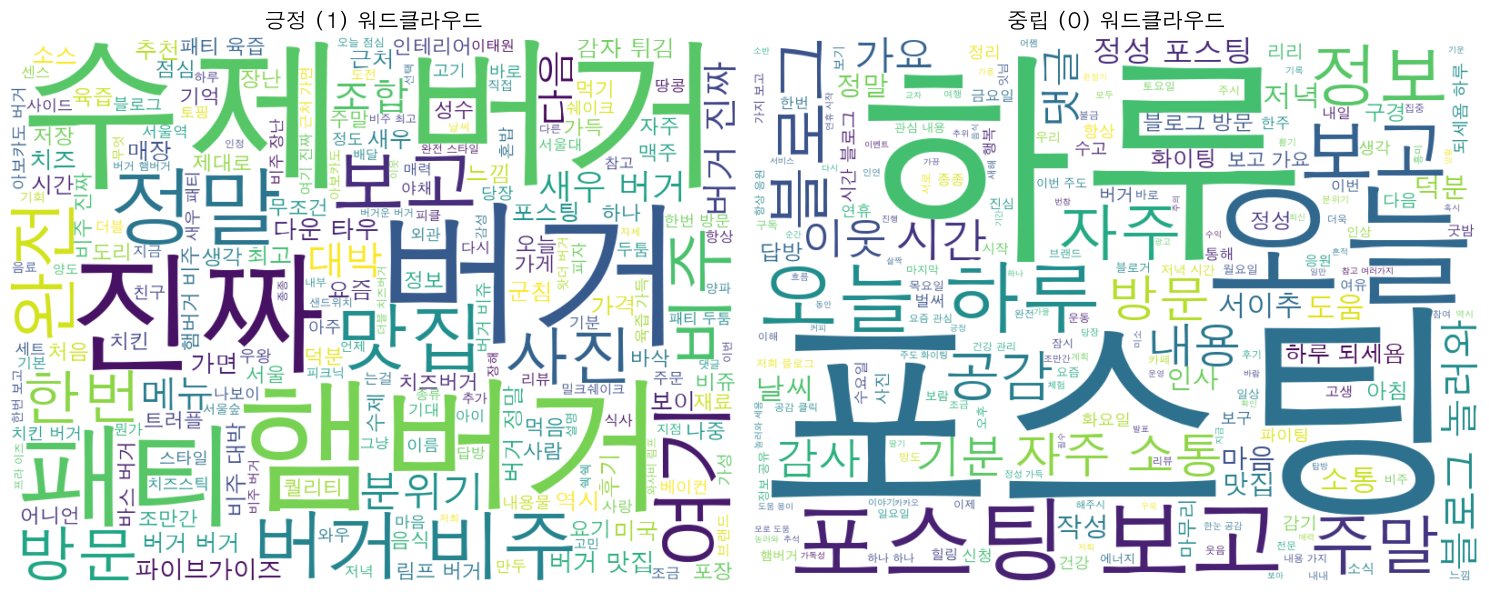

In [71]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 


# 1. 데이터 로드
df = pd.read_csv('서울_버거_감성분석_sentiment_predict.csv')

# 2. NaN 제거
df = df.dropna(subset=['comment_clean', 'sentiment_predict'])

# 3. 긍정 / 중립 분리
positive_text = " ".join(
    df[df['sentiment_predict'] == 1]['comment_clean'].astype(str)
)

neutral_text = " ".join(
    df[df['sentiment_predict'] == 0]['comment_clean'].astype(str)
)

# 4. 워드클라우드 생성 함수
def make_wordcloud(text, title, ax):
    wc = WordCloud(
        font_path='/System/Library/Fonts/Supplemental/AppleGothic.ttf',   # 한글 폰트
        background_color='white',
        width=800,
        height=600
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=15)
    ax.axis('off')

# 5. 시각화 (2개 비교)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

make_wordcloud(positive_text, "긍정 (1) 워드클라우드", axes[0])
make_wordcloud(neutral_text, "중립 (0) 워드클라우드", axes[1])


plt.tight_layout()
plt.show()
